In [1]:
import scanpy as sc 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

import scipy.sparse as sp 
import warnings
import torch

warnings.filterwarnings("ignore")

import os
import ctypes
import sys

# 1. 先设置 R_HOME
os.environ["R_HOME"] = "/home/pxy/miniconda3/envs/r40/lib/R"

# 2. 【核心黑科技】手动加载 R 的动态库
# 这步操作等同于在终端里设置 LD_LIBRARY_PATH，专门解决 VS Code 找不到库的问题
try:
    # 这是 R 的核心库路径
    libR_path = "/home/pxy/miniconda3/envs/r40/lib/R/lib/libR.so"
    # 强制加载进内存
    ctypes.CDLL(libR_path, mode=ctypes.RTLD_GLOBAL)
    print("✅ 成功强制加载 libR.so")
except OSError as e:
    print(f"❌ 加载失败: {e}")

# 3. 然后再导入其他包
sys.path.append("..") 

import models
import rpy2.robjects as robjects
print("R 环境路径:", robjects.r['R.home']()[0])

models.fix_seed(0)

✅ 成功强制加载 libR.so
R 环境路径: /home/pxy/miniconda3/envs/r40/lib/R


In [2]:
import scanpy as sc
import pandas as pd
import os


data_dir = '/home/pxy/home/pxy/data/Human_Breast_Cancer/'
n_clusters = 20 


adata = sc.read_visium(data_dir)
adata.var_names_make_unique()


meta = pd.read_csv(os.path.join(data_dir, "metadata.tsv"), sep="\t")


meta = meta.set_index("ID")


adata.obs["Region"] = meta.loc[adata.obs_names, "ground_truth"]


print(f"Dataset: Human Breast Cancer (HBC)")
print(f"Total Spots: {adata.n_obs}")
print(f"Available Labels: {adata.obs['Region'].nunique()}")
print(f"NA spots in Region: {adata.obs['Region'].isna().sum()}")


print("\nAnnotation details:")
print(adata.obs["Region"].value_counts())

Dataset: Human Breast Cancer (HBC)
Total Spots: 3798
Available Labels: 20
NA spots in Region: 0

Annotation details:
Region
IDC_5           449
IDC_4           442
Healthy_1       411
IDC_2           383
IDC_8           364
Tumor_edge_1    198
Tumor_edge_6    182
Tumor_edge_2    165
IDC_6           163
DCIS/LCIS_4     161
Tumor_edge_3    159
DCIS/LCIS_5     139
DCIS/LCIS_1     135
IDC_7           127
Healthy_2        74
Tumor_edge_5     69
IDC_3            53
Tumor_edge_4     50
IDC_1            46
DCIS/LCIS_2      28
Name: count, dtype: int64


In [3]:
cluster_palette = sc.pl.palettes.vega_20
figures_dir = "figures_HBC_best_test"


In [4]:
adata = models.preprocess(adata)
adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
g_spatia = models.prepare_graph(adata, "spatial",n_neighbors=6)
g_expr = models.prepare_graph(adata, "expr", metric="euclidean",n_neighbors=11)
graph_dict = {"spatial": g_spatia, "expr":g_expr}

normalized data ---------------->
正在构建图: spatial, 使用度量: cosine ...
  -> 使用空间坐标 (euclidean)
  -> 计算最近邻 (NearestNeighbors)...
  -> 对称化与归一化...
spatial graph created successfully <----

正在构建图: expr, 使用度量: euclidean ...
  -> 使用 PCA 降维特征 
  -> 计算最近邻 (NearestNeighbors)...
  -> 对称化与归一化...
expr graph created successfully <----



In [5]:
model = models.model_TwoStage(
    adata.obsm["X_pca"], 
    graph_dict, 
    n_clusters=n_clusters,
    dim_input=200,
    pretrain_epochs=100,   # 预训练200轮
    finetune_epochs=100,   # 训练300轮
    gamma=0.0,             # 重构损失权重
    kappa=1.5,             # 对比损失权重
    theta=2.0,
    dim_hidden=32,
    freeze_encoder=False,   # 冻结预训练编码器
    graph_corr=0.2,
    dropout=0.2,
    gate_bias=3.0,
    residual_weight=0.2
)

In [6]:
pred, embed, gated_weights = model.train()

Stage 1: Pre-training Shared Encoder


Pretrain:  25%|██▌       | 25/100 [00:01<00:03, 24.39it/s]

  Pretrain Epoch 10: Rec Loss = 18.073221
  Pretrain Epoch 20: Rec Loss = 17.635347
  Pretrain Epoch 30: Rec Loss = 17.045633
  Pretrain Epoch 40: Rec Loss = 16.929102


Pretrain:  66%|██████▌   | 66/100 [00:02<00:00, 65.26it/s]

  Pretrain Epoch 50: Rec Loss = 16.739580
  Pretrain Epoch 60: Rec Loss = 16.633036


...

  Train Epoch 80: Loss = 12.252833,Rec Loss = 18.217670, Contrast Loss = 8.112031, Smooth Loss = 0.042393


Finetune:  91%|█████████ | 91/100 [00:13<00:01,  6.42it/s]

  Train Epoch 90: Loss = 12.230065,Rec Loss = 18.223600, Contrast Loss = 8.102463, Smooth Loss = 0.038186


Finetune: 100%|██████████| 100/100 [00:15<00:00,  6.58it/s]

  Train Epoch 100: Loss = 12.207249,Rec Loss = 18.228413, Contrast Loss = 8.092718, Smooth Loss = 0.034086

  Finetune Epoch 100:
    Total Loss   = 12.2072
    Rec Loss     = 18.2284
    Contrast Loss = 8.0927
    Smooth Loss = 0.0341

✓ Finetune finished (max epochs reached)


In [7]:
adata.obsm["model_twostage"] = embed
models.clustering(adata, n_clusters, key="model_twostage", refinement=True,radius=10,cluster_methods='kmeans')


adata_filtered = adata[adata.obs.Region.notna()]
ARI_kmeans = adjusted_rand_score(adata_filtered.obs["Region"], 
                          adata_filtered.obs["kmeans_refined"])
print(f"\nFinal ARI: {ARI_kmeans:.4f}")



Final ARI: 0.6976


In [8]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score
mask = adata.obs.Region.notna()
X = embed[mask]
labels = adata.obs["kmeans_refined"][mask]

# 1. 计算 SC 指数
sc_val = silhouette_score(X, labels)

# 2. 计算 CH 指数
ch_val = calinski_harabasz_score(X, labels)


print(f"Silhouette Coefficient (SC): {sc_val:.4f}")
print(f"Calinski-Harabasz Index (CH): {ch_val:.4f}")

Silhouette Coefficient (SC): 0.4356
Calinski-Harabasz Index (CH): 4853.4923


In [9]:
from sklearn.metrics import normalized_mutual_info_score


adata_filtered = adata[adata.obs.Region.notna()]


NMI_kmeans = normalized_mutual_info_score(adata_filtered.obs["Region"], 
                                          adata_filtered.obs["kmeans_refined"])

print(f"\nFinal Results on:")
print(f"ARI: {ARI_kmeans:.4f}")
print(f"NMI: {NMI_kmeans:.4f}")


Final Results on:
ARI: 0.6976
NMI: 0.7026


In [10]:
from sklearn.metrics import adjusted_mutual_info_score, fowlkes_mallows_score

ami = adjusted_mutual_info_score(adata_filtered.obs["Region"], adata_filtered.obs["kmeans_refined"])
fmi = fowlkes_mallows_score(adata_filtered.obs["Region"], adata_filtered.obs["kmeans_refined"])
print(f"Adjusted Mutual Information (AMI): {ami:.4f}")
print(f"Fowlkes-Mallows Index (FMI): {fmi:.4f}")

Adjusted Mutual Information (AMI): 0.6970
Fowlkes-Mallows Index (FMI): 0.7234


In [11]:
sample_name="HBC"

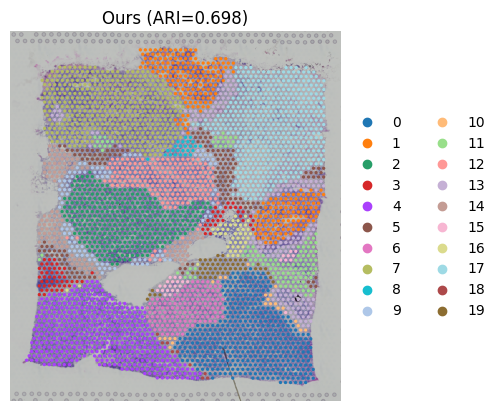

In [13]:
adata_filtered.obs["model"] = adata_filtered.obs["kmeans_refined"]
sc.pl.spatial(adata_filtered, color=["model"], show=False, frameon=False, title=[f"Ours (ARI={round(ARI_kmeans, 3)})"])
plt.savefig(f"{figures_dir}/{sample_name}_spatial_plot.png", dpi=300, bbox_inches='tight')
# 保存 SVG（矢量图，论文首选）
plt.savefig(f"{figures_dir}/{sample_name}_spatial_plot.svg", bbox_inches='tight')
# 保存 PDF（期刊常用）
plt.savefig(f"{figures_dir}/{sample_name}_spatial_plot.pdf", bbox_inches='tight')
plt.show()
plt.close()


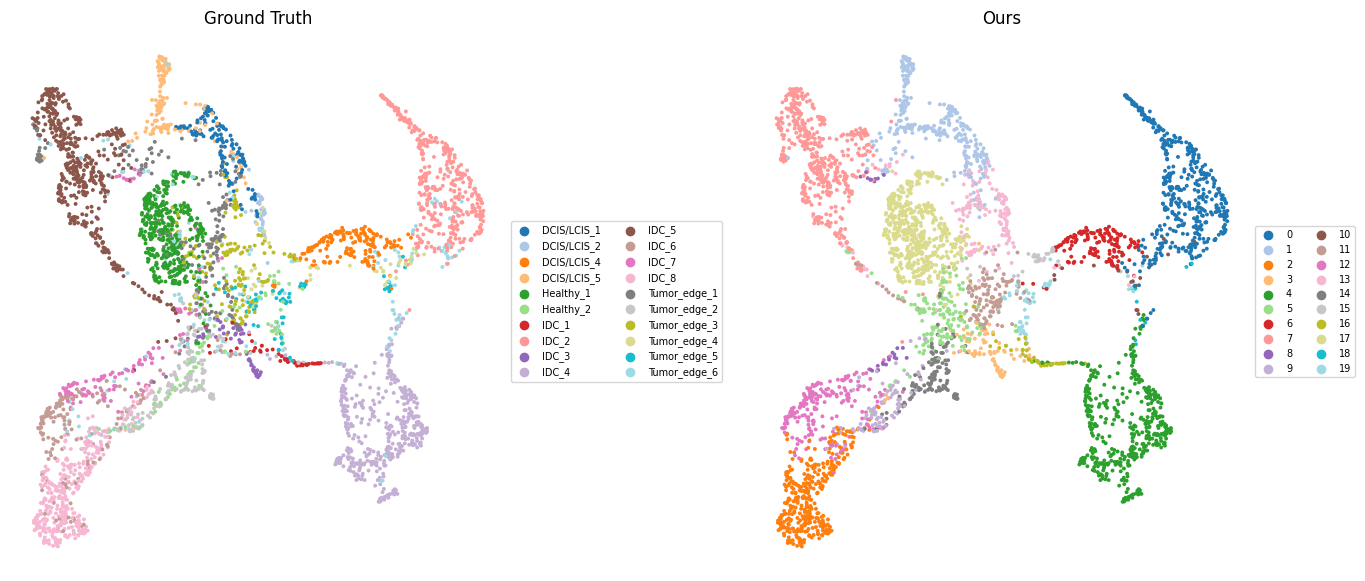

In [ ]:
adata.obsm["embed"] = embed
sc.pp.neighbors(adata, n_neighbors=15, use_rep="embed")

# 计算 UMAP
sc.tl.umap(adata)
sc.settings.vector_friendly = True
# # 绘图：同时查看 Ground Truth (Region) 和 你的聚类结果 (kmeans_refined)
# # 这样可以直观对比哪些区域分错了
# sc.pl.umap(adata, color=["Region", "kmeans_refined"], 
#            title=["Ground Truth", "Ours"],
#            show=False)

# # 保存图片
# plt.savefig(f"{figures_dir}/HBC_umap.png", bbox_inches='tight')
# plt.show()
# plt.close()
import matplotlib.pyplot as plt
import scanpy as sc

# 1. 增加画布宽度 (从默认大小改为 18x7)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 使用 20 类专用色板，防止颜色重复
cluster_palette = sc.pl.palettes.vega_20

# 2. 绘制第一个子图 (Ground Truth)
sc.pl.umap(
    adata, 
    color="Region", 
    title="Ground Truth",
    ax=axes[0], 
    show=False,
    palette=cluster_palette,
    frameon=False
)
# 强制将左侧图例改为 2 列并缩小字号
axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, fontsize=7)

# 3. 绘制第二个子图 (Ours)
sc.pl.umap(
    adata, 
    color="kmeans_refined", 
    title="Ours",
    ax=axes[1], 
    show=False,
    palette=cluster_palette,
    frameon=False
)
# 强制将右侧图例改为 2 列并缩小字号
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, fontsize=7)

# 4. 调整子图间距，给右侧图例留出足够空间
plt.subplots_adjust(wspace=0.5) 

# 5. 先保存图片 (确保 bbox_inches='tight' 自动包含溢出的图例)
save_path = f"{figures_dir}/HBC_umap_fixed_6_11.png"
plt.savefig(f"{figures_dir}/{sample_name}_umap_fixed_6_11.png", bbox_inches='tight',dpi=300)
plt.savefig(f"{figures_dir}/{sample_name}_umap_fixed_6_11.svg", bbox_inches='tight')
plt.savefig(f"{figures_dir}/{sample_name}_umap_fixed_6_11.pdf", bbox_inches='tight')
plt.show()
plt.close()

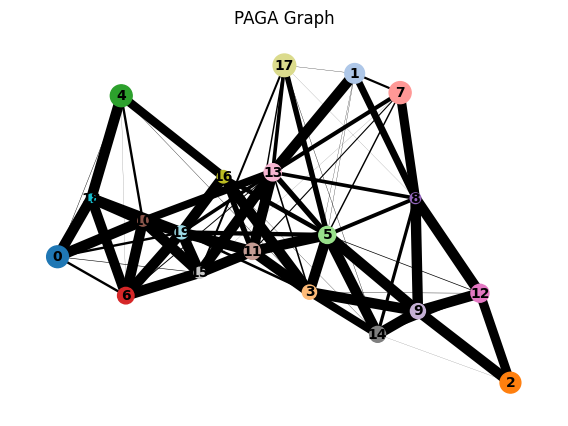

In [15]:
# 计算 PAGA
# groups 指定聚类结果所在的 obs 列名
sc.tl.paga(adata, groups="kmeans_refined")

# 绘图
# plot_threshold 可以控制显示连通性的阈值
sc.pl.paga(adata, color="kmeans_refined", 
           title=f"PAGA Graph",
           show=False,frameon=False)

# 保存图片

plt.savefig(f"{figures_dir}/{sample_name}_paga.png", bbox_inches='tight',dpi=300)
plt.savefig(f"{figures_dir}/{sample_name}_paga.svg", bbox_inches='tight')
plt.savefig(f"{figures_dir}/{sample_name}_paga.pdf", bbox_inches='tight')
plt.show()
plt.close()


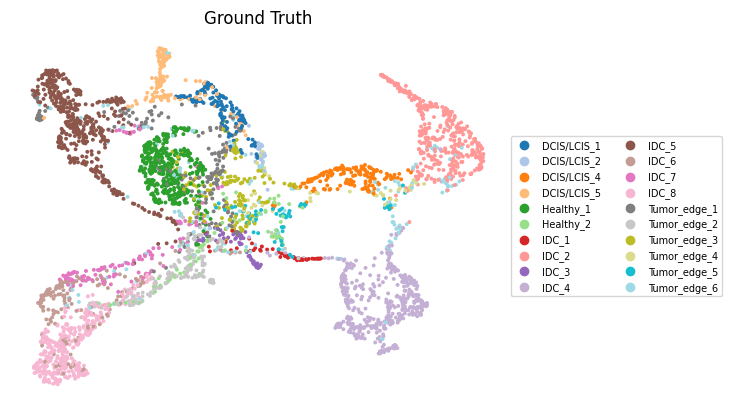

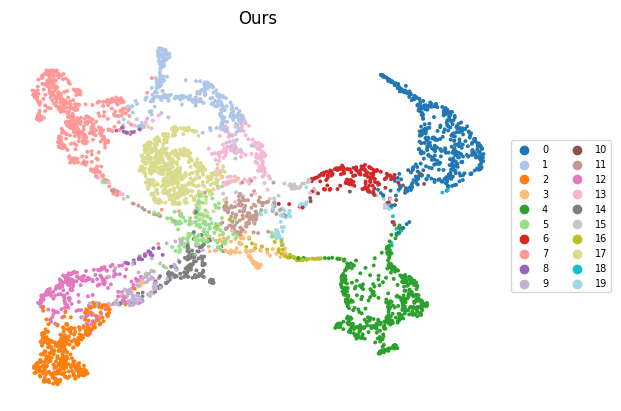

In [16]:
import matplotlib.pyplot as plt
import scanpy as sc


# ===================== 图1：单独画 Ground Truth =====================
sc.pl.umap(
    adata,
    color="Region",
    title="Ground Truth",
    palette=cluster_palette,
    frameon=False,
    show=False
)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, fontsize=7)
plt.savefig(f"{figures_dir}/HBC_umap_ground_truth.png", bbox_inches='tight', dpi=300)
plt.savefig(f"{figures_dir}/HBC_umap_ground_truth.svg", bbox_inches='tight')
plt.savefig(f"{figures_dir}/HBC_umap_ground_truth.pdf", bbox_inches='tight')
plt.show()
plt.close()

# ===================== 图2：单独画 模型结果 Ours =====================
sc.pl.umap(
    adata,
    color="kmeans_refined",
    title="Ours",
    palette=cluster_palette,
    frameon=False,
    show=False
)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, fontsize=7)
plt.savefig(f"{figures_dir}/HBC_umap_ours.png", bbox_inches='tight', dpi=300)
plt.savefig(f"{figures_dir}/HBC_umap_ours.svg", bbox_inches='tight')
plt.savefig(f"{figures_dir}/HBC_umap_ours.pdf", bbox_inches='tight')
plt.show()
plt.close()

